# 階層式 GAM 迴歸示範

使用 `MixedGAMRegressor` 展示 Group Residual 與 Group Affine 兩種階層調整模式，並繪製共享 shape function 與群組覆疊曲線。


## 1. 環境準備
載入必要套件與自訂模型模組。


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.models import MixedGAMRegressor, MixedGAMConfig

plt.style.use('seaborn-v0_8')
np.random.seed(42)

## 2. 公開資料載入與群組欄位
以 UCI Student Performance (Portuguese) 為例，利用 `school` 與 `address` 組合成群組階層。


In [2]:
DATA_URL = '../data/student-por.csv'
raw = pd.read_csv(DATA_URL)

feature_cols = ['age', 'absences', 'G1', 'G2', 'studytime', 'Medu', 'Fedu', 'traveltime', 'failures']
df = raw[feature_cols + ['G3', 'school', 'address']].copy()
df['group'] = df['school'].astype(str) + '_' + df['address'].astype(str)

X = df[feature_cols]
y = df['G3']
groups = df['group']

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X,
    y,
    groups,
    test_size=0.25,
    random_state=42,
    stratify=groups,
)

print(f'訓練資料：{X_train.shape}, 測試資料：{X_test.shape}')
print('群組樣本數：')
display(pd.Series(g_train).value_counts())

訓練資料：(486, 9), 測試資料：(163, 9)
群組樣本數：


group
GP_U    258
MS_R     89
MS_U     80
GP_R     59
Name: count, dtype: int64

In [3]:
y.describe()

count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64

In [4]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
# === CatBoost baseline ===
cb = CatBoostRegressor(verbose=0, random_seed=42)
cb.fit(X_train, y_train)  # ① fit
y_pred = cb.predict(X_test)  # ② predict
print("MSE:", mean_squared_error(y_test, y_pred), "R2:", r2_score(y_test, y_pred))  # ③ KPI

MSE: 1.2692118677743287 R2: 0.8699811454545954


## 3. 模式一：Group Residual (FiLM/LoRA)
Lightning 訓練 + 評估，並顯示單特徵 shape 與群組疊圖。


### 正則化設計（Residual / Affine 模式）

總 loss 由三段組成：

$$\mathcal{L}_{total} = \text{MSE}(\hat{y}, y) + \lambda_{base}\,\text{MSE}(f_{base}, y) + \lambda_{center}(\mathbb{E}[r_g])^2 + \lambda_{L1}||W_g||_1 + \lambda_{L2}||W_g||_2 + \lambda_{orth}\cdot\text{Cov}(f_{base}, \Delta_g)^2$$

- $f_{base}$：所有特徵 shape 的總和（shared GAM）。
- $r_g$ / $\Delta_g$：群組殘差或 affine 校正項。
- $\lambda_{base}$ 對應 `lambda_base_target`，強迫共享 trunk 擔任主要趨勢。
- 其它係數分別控制群組平均為零、稀疏/小幅度，以及與共享基底的正交性。


In [5]:
residual_model = MixedGAMRegressor(
    mode='group_residual',
    n_epochs=100,
    batch_size=64,
    learning_rate=2e-3,
    verbose=True,
)
residual_model.fit(X_train, y_train, groups=g_train)
residual_preds = residual_model.predict(X_test, groups=g_test)
residual_mse = mean_squared_error(y_test, residual_preds)
print(f'Group Residual 模式 MSE: {residual_mse:.3f}', "R2:", r2_score(y_test, y_pred))  # ③ KPI


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


[MixedGAM] Training mode=group_residual via PyTorch Lightning...
                                                                           

d:\Code\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
d:\Code\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 99: 100%|██████████| 7/7 [00:00<00:00, 70.48it/s, val_loss=1.9980, mode=group_residual, epoch=99, train_loss=1.3286, lr=2.00e-03]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 7/7 [00:00<00:00, 69.09it/s, val_loss=1.9980, mode=group_residual, epoch=99, train_loss=1.3286, lr=2.00e-03]
[MixedGAM] Finished training. Last loss=0.11355
Group Residual 模式 MSE: 1.174 R2: 0.8699811454545954


In [5]:
from dataclasses import asdict

cfg = MixedGAMConfig(
    mode="group_residual",  # 或 "group_affine"
    scaler="standard",  # "standard" / "robust" / "none"
    base_hidden_units=(128, 64),  # 會餵給 BaseGAM 的 per-feature MLP
    base_activation="tanh",
    base_dropout=0.1,
    residual_hidden_units=(64, ),  # 只在 group_residual 模式會用到
    residual_activation="relu",
    residual_dropout=0.1,
    learning_rate=2e-3,
    weight_decay=1e-4,
    batch_size=128,
    n_epochs=200,
    lambda_center=1,
    lambda_group_l1=1e-4,
    lambda_group_l2=1e-4,
    lambda_orth=1e-4,
    lambda_affine_scale=1e-4,  # 只在 group_affine 模式會用到
    lambda_affine_shift=1e-4,  # 只在 group_affine 模式會用到
    lambda_affine_center=1e-4,  # 只在 group_affine 模式會用到
    lambda_base_target=1e-3,  # 讓 base_sum 對齊 y 的輕度監督
    verbose=True,
    random_state=42,
    device=None,  # None 自動用 CUDA/CPU
    num_shape_points=200,
)

residual_model = MixedGAMRegressor(
    metric_fn=None,  # 可自訂 metric；預設是 MSE
    auto_search=False,  # 若想同時做搜尋，改 True，並搭配 search_space
    **asdict(cfg)  # <-- 關鍵：把 dataclass 轉成 dict 並展開
)

residual_model.fit(X_train, y_train, groups=g_train)
y_pred = residual_model.predict(X_test, groups=g_test)


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


[MixedGAM] Training mode=group_residual via PyTorch Lightning...
                                                                            

d:\Code\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
d:\Code\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 199: 100%|██████████| 4/4 [00:00<00:00, 45.68it/s, val_loss=1.9212, mode=group_residual, epoch=199, train_loss=1.4581, lr=2.00e-03]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 4/4 [00:00<00:00, 44.17it/s, val_loss=1.9212, mode=group_residual, epoch=199, train_loss=1.4581, lr=2.00e-03]
[MixedGAM] Finished training. Last loss=0.67702


In [6]:
residual_model.feature_importance(X_test, groups=g_test)

{'age': 1.3757637739181519,
 'absences': 1.4600492715835571,
 'G1': 0.9342097043991089,
 'G2': 2.117152690887451,
 'studytime': 1.5286039113998413,
 'Medu': 0.9053404927253723,
 'Fedu': 0.9831587076187134,
 'traveltime': 1.5370333194732666,
 'failures': 1.3347550630569458}

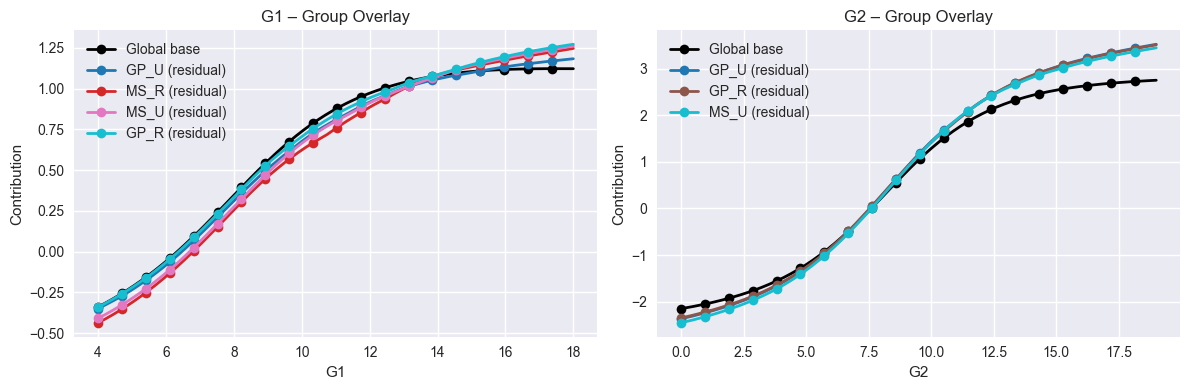

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
residual_model.plot_feature_shapes('G1', ax=ax[0])
residual_model.plot_feature_shapes('G2', groups=['GP_U', 'GP_R', 'MS_U'], ax=ax[1])
plt.tight_layout()
plt.show()

In [28]:
pred, contrib = residual_model.predict_and_contrib(X_test, groups=g_test)

In [31]:
contrib.keys()

dict_keys(['per_feature', 'base_per_feature', 'residual_per_feature', 'bias', 'residual_sum'])

In [34]:
contrib['per_feature'].sum(axis=1)[:10] + contrib['bias'][:10]  # 應該等於 pred[:10]

array([16.23897 , 11.187355,  9.517148, 11.544834,  9.730394, 12.134637,
        5.170794,  8.229169, 13.369365,  8.301972], dtype=float32)

In [36]:
contrib['base_per_feature'].sum(
    axis=1)[:10] + contrib['residual_per_feature'].sum(
        axis=1)[:10] + contrib['bias'][:10]  # 應該等於 pred[:10]

array([16.238972 , 11.187354 ,  9.517148 , 11.544834 ,  9.730394 ,
       12.134636 ,  5.1707935,  8.229168 , 13.369366 ,  8.301972 ],
      dtype=float32)

In [39]:
contrib['base_per_feature'].sum(axis=1)[:10]

array([15.596398, 10.527231,  8.909563, 11.938271,  9.999087, 13.168897,
        6.354359,  7.56863 , 13.297963,  8.251407], dtype=float32)

In [41]:
contrib['residual_per_feature'][:10]

array([[-0.2696974 , -0.02851474,  0.37710428, -0.09419554,  0.26189712,
         0.12849815,  0.15367286, -0.02517943,  0.11585495],
       [-0.24139842, -0.52281904, -0.0293991 ,  0.47921547,  0.70106775,
        -0.3853557 ,  0.38141692,  0.41127092, -0.15700938],
       [-0.12259403,  0.04505035,  0.28695577, -0.00365659,  0.34942913,
         0.2654582 , -0.109153  , -0.17074963,  0.04371193],
       [-0.31810609,  0.06652163,  0.26765755,  0.00104844,  0.03760729,
         0.08681314, -0.27309054, -0.2652743 , -0.01974688],
       [-0.31986958,  0.11613327,  0.31089586, -0.01541658,  0.15326548,
         0.14051463, -0.39140445, -0.3915463 ,  0.10560172],
       [-0.24642959, -0.1832519 ,  0.20394394,  0.00224205,  0.00602246,
        -0.2166639 , -0.31675446, -0.20042206, -0.10608049],
       [-0.64809835, -0.00540861,  0.10944007,  0.39469457,  0.08547868,
        -0.11584897, -0.45252347, -0.6429411 ,  0.06850899],
       [-0.03091909, -0.23665552,  0.30125585,  0.30859938,  0

In [35]:
pred[:10]

array([16.238972 , 11.187355 ,  9.517148 , 11.544833 ,  9.730395 ,
       12.134636 ,  5.1707935,  8.229168 , 13.369367 ,  8.301972 ],
      dtype=float32)

### Feature-level contributions & residual bias
`predict_and_contrib` exposes the shared additive trunk as well as the group-specific bias term. The residual-mode decomposition follows
\(\hat{y} = \sum_j f_j(x_j) + r_g\), so the bias lives in `group_residual`.


In [ ]:
[
    'per_feature', 'base_per_feature', 'residual_per_feature', 'bias',
    'residual_sum'
]

In [12]:
res_contrib['base_per_feature'].sum(
    axis=1)[:10] + res_contrib['residual_per_feature'].sum(
        axis=1)[:10] + res_contrib['bias'][:10]  # 應該等於 pred[:10]

array([15.749022, 10.740654,  9.368709], dtype=float32)

In [13]:
res_contrib['residual_per_feature'].sum(axis=1)[:10]

array([4.411126 , 2.3524835, 1.3535569], dtype=float32)

In [16]:
res_contrib['residual_sum'][:10]

array([4.411126 , 2.3524835, 1.3535569], dtype=float32)

In [21]:
res_rows = X_test.head(3)
res_groups = g_test.head(3).tolist()
res_preds, res_contrib = residual_model.predict_and_contrib(res_rows, groups=res_groups)

res_per_feature = pd.DataFrame(
    res_contrib['per_feature'],
    columns=residual_model.feature_names,
    index=res_rows.index,
)
res_per_feature['base_sum'] = res_per_feature.sum(axis=1) + res_contrib['bias']
res_per_feature['residual_bias'] = res_contrib['residual_sum']
res_per_feature['reconstructed'] = res_per_feature['base_sum']
res_per_feature['prediction'] = res_preds

display(res_per_feature.round(3))
print('Max |prediction - reconstructed|:',
      np.abs(res_per_feature['prediction'] - res_per_feature['reconstructed']).max())


,age,absences,G1,G2,studytime,Medu,Fedu,traveltime,failures,base_sum,residual_bias,reconstructed,prediction
8,1.330,1.257,1.746,3.165,2.133,1.729,1.221,1.632,1.515,15.749,4.411,15.749,15.749
458,1.489,1.765,0.711,1.705,2.108,0.510,0.067,0.463,1.900,10.741,2.352,10.741,10.741
573,1.739,2.095,-0.152,1.288,1.043,-0.014,0.515,2.026,0.807,9.369,1.354,9.369,9.369


Max |prediction - reconstructed|: 9.536743e-07


## 4. 模式二：Group Affine (線性縮放)
每個特徵曲線可被各群組重新縮放與平移。


In [8]:
affine_model = MixedGAMRegressor(
    mode='group_affine',
    n_epochs=200,
    batch_size=64,
    learning_rate=2e-3,
    verbose=True,
)
affine_model.fit(X_train, y_train, groups=g_train)
affine_preds = affine_model.predict(X_test, groups=g_test)
affine_mse = mean_squared_error(y_test, affine_preds)
print(f'Group Affine 模式 MSE: {affine_mse:.3f}')


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


[MixedGAM] Training mode=group_affine via PyTorch Lightning...
                                                                            

d:\Code\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
d:\Code\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 199: 100%|██████████| 7/7 [00:00<00:00, 69.31it/s, val_loss=1.8186, mode=group_affine, epoch=199, train_loss=1.7761, lr=2.00e-03]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 7/7 [00:00<00:00, 67.96it/s, val_loss=1.8186, mode=group_affine, epoch=199, train_loss=1.7761, lr=2.00e-03]
[MixedGAM] Finished training. Last loss=0.28869
Group Affine 模式 MSE: 1.143


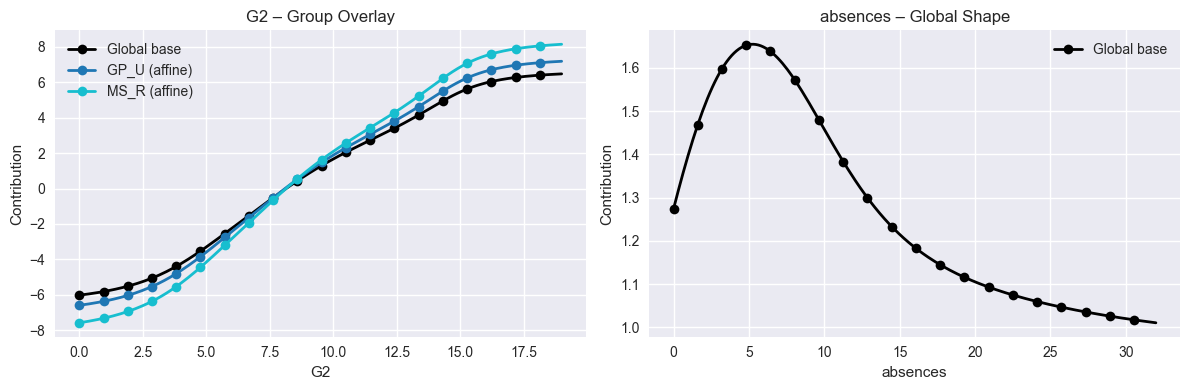

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
affine_model.plot_feature_shapes('G2', groups=['GP_U', 'MS_R'], ax=ax[0])
affine_model.plot_feature_shapes('absences', mode='global', ax=ax[1])
plt.tight_layout()
plt.show()


In [16]:
pred, contrib = affine_model.predict_and_contrib(X_test, groups=g_test)

In [22]:
pred[:10]

array([16.138384 , 10.846147 ,  8.732617 , 11.953905 ,  9.99444  ,
       13.58597  ,  6.9296713,  8.779829 , 13.681738 ,  8.315004 ],
      dtype=float32)

In [ ]:
contrib['per_feature'].sum(axis=1)[:10]

array([-1.9073486e-06,  9.5367432e-07,  9.5367432e-07,  9.5367432e-07,
       -1.9073486e-06,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00], dtype=float32)

In [26]:
contrib['bias']

array([0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159146,
       0.42159146, 0.42159146, 0.42159146, 0.42159146, 0.42159

### Group-affine contribution tables
In affine mode `per_feature` already includes the calibrated group effect, while `base_per_feature` keeps the shared trunk. Summing the adjusted features reproduces the prediction exactly.


In [10]:
aff_rows = X_test.head(3)
aff_groups = g_test.head(3).tolist()
aff_preds, aff_contrib = affine_model.predict_and_contrib(aff_rows, groups=aff_groups)

aff_base = pd.DataFrame(
    aff_contrib['base_per_feature'],
    columns=affine_model.feature_names,
    index=aff_rows.index,
)
aff_adjusted = pd.DataFrame(
    aff_contrib['per_feature'],
    columns=affine_model.feature_names,
    index=aff_rows.index,
)
aff_summary = pd.concat({
    'base_shared': aff_base,
    'group_affine': aff_adjusted,
}, axis=1)
aff_summary[('group_affine', 'sum')] = aff_adjusted.sum(axis=1)
aff_summary[('diagnostics', 'prediction')] = aff_preds

display(aff_summary.round(3))
print('Max |prediction - sum|:',
      np.abs(aff_summary[('group_affine', 'sum')] - aff_summary[('diagnostics', 'prediction')]).max())


base_shared                                                            \
            age absences     G1     G2 studytime   Medu   Fedu traveltime   
8         1.272    1.274  1.013  5.963     1.182  0.889  1.270      1.212   
458       1.471    1.274  0.374  1.664     1.107  0.660  1.242      1.784   
573       1.535    1.519 -0.600  0.818     1.038  0.660  1.242      1.212   

             group_affine                                                 \
    failures          age absences     G1     G2 studytime   Medu   Fedu   
8      1.227        1.319    1.232  0.977  6.622     1.227  0.885  1.314   
458    1.227        1.367    1.368  0.401  2.093     1.046  0.595  1.164   
573    1.227        1.508    1.530 -0.601  0.963     0.986  0.682  1.242   

                                diagnostics  
    traveltime failures     sum  prediction  
8        1.283    1.279  16.138      16.138  
458      1.684    1.129  10.846      10.846  
573      1.207    1.215   8.733       8.733

Max |prediction - sum|: 1.9073486e-06


## 5. 工具函式：Shape Function & Group 曲線
使用 `get_feature_shape` 與 `get_group_affine_shape` 取得曲線資料，以利自訂視覺化。


In [ ]:
grid, global_shape = affine_model.get_feature_shape('G2')
_, group_shape = affine_model.get_group_affine_shape('G2', 'GP_U')
shape_df = pd.DataFrame({'G2': grid, 'global_shape': global_shape, 'GP_U_shape': group_shape})
shape_df.head()


## 參數可調總覽

| 參數 | 說明 |
| --- | --- |
| `mode` | `group_residual` 或 `group_affine`。 |
| `scaler` | `standard` / `robust` / `none`。 |
| `base_hidden_units` | GAM trunk 每個特徵 MLP 結構。 |
| `base_activation` / `base_dropout` | Trunk 啟動函式與 dropout。 |
| `residual_hidden_units` / `residual_activation` / `residual_dropout` | 殘差頭部網路。Affine 模式僅需 `n_features * n_groups` 參數。 |
| `learning_rate`, `weight_decay`, `batch_size`, `n_epochs` | Lightning 訓練控制。 |
| `lambda_center`, `lambda_group_l1`, `lambda_group_l2`, `lambda_orth` | 限制群組殘差的平均、稀疏與正交。 |
| `lambda_affine_scale`, `lambda_affine_shift`, `lambda_affine_center` | Affine 縮放/平移正則。 |
| `lambda_base_target` | 新增：迫使共享 GAM 直接逼近整體趨勢。 |
| `num_shape_points` | shape function 評估網格密度。 |
| `auto_search`, `search_space`, `search_val_ratio`, `search_metric` | 是否自動啟動超參數搜尋及其設定。 |
| `metric_fn` | 推論階段自訂 KPI。 |
| `device`, `verbose` | 裝置與訓練過程輸出。


## 6. 自訂指標 + Lightning 超參數搜尋
以下示範以 Ray Tune 配合 RMSE 作為離線檢查指標，實際搜尋依然使用 Lightning 回報的 `val_loss`。


In [ ]:
from ray import tune
from sklearn.model_selection import train_test_split


def rmse(y_true, y_pred):
    return float(np.sqrt(((y_true - y_pred) ** 2).mean()))

X_tr, X_va, y_tr, y_va, g_tr_split, g_va = train_test_split(
    X_train,
    y_train,
    g_train,
    test_size=0.2,
    random_state=42,
    stratify=g_train,
)

search_space = {
    "learning_rate": tune.loguniform(5e-4, 5e-3),
    "residual_dropout": tune.choice([0.0, 0.2]),
    "base_hidden_units": tune.choice([(64, 32), (128, 64)]),
}

search_result = MixedGAMRegressor.ray_tune_search(
    X=X_tr,
    y=y_tr,
    groups=g_tr_split,
    param_space=search_space,
    num_samples=10,
    metric="val_loss",
    mode="min",
    val_ratio=0.2,
    max_epochs=120,
)

best_cfg = search_result["best_config"]
print("Ray Tune 最佳 val_loss:", search_result["best_metric"])
print("Ray Tune 最佳參數:", best_cfg)

best_model = MixedGAMRegressor(**best_cfg)
best_model.fit(
    X_tr,
    y_tr,
    groups=g_tr_split,
    X_val=X_va,
    y_val=y_va,
    groups_val=g_va,
)

val_preds = best_model.predict(X_va, groups=g_va)
print("Holdout RMSE:", rmse(y_va, val_preds))


## Tuning 與 Metric 擴充說明
- `ray_tune_search` 會切出 validation set（`val_ratio`），依照 Lightning 的 `metric` 名稱回報結果，預設為 `val_loss`。
- 搜尋得到 `best_config` 後，可重新訓練模型並套用自訂指標（如上例的 `rmse`）作為離線評估。
- 設定 `auto_search=True` 會啟用 Ray Tune 的預設空間（可覆寫 `search_space`），找到參數後才進入完整訓練。


### （選用）自動化超參數搜尋示例
設定 `auto_search=True` 後會先試跑預設空間（可透過 `search_space` 自訂），找到最佳參數後才進入完整訓練。


In [ ]:
auto_model = MixedGAMRegressor(
    mode='group_residual',
    auto_search=True,
    n_epochs=120,
    batch_size=64,
    verbose=True,
)
auto_model.fit(X_train, y_train, groups=g_train)
auto_preds = auto_model.predict(X_test, groups=g_test)
auto_mse = mean_squared_error(y_test, auto_preds)
print(f'Auto-search 模式 MSE: {auto_mse:.3f}')


## 7. 未知群組回退機制
對未看過的群組名稱，自動退回共享 GAM 形狀（殘差趨近 0）。


In [ ]:
novel_groups = ['ZZ_X'] * 5
sample = X_test.head(5)
preds, contrib = residual_model.predict_and_contrib(sample, groups=novel_groups)
display(pd.DataFrame({
    'group': novel_groups,
    'prediction': preds,
    'residual': contrib['group_residual'],
}))
